<div style="background-color:#1B4F72; padding:22px; border-radius:10px; border-left:8px solid #AED6F1;">
<h1 style="color:#F2F3F4; margin-bottom:0;"><b>Machine Learning II — Customer Segmentation</b></h1>
<h3 style="color:#AED6F1; margin-top:6px;">Notebook 5 — Association Rules per Segment</h3>
</div>

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
This notebook mines association rules from customer transaction data, separately for each customer segment. The goal is to identify co-purchase patterns that are specific to each segment and translate them into actionable promotional campaign suggestions.
</div>

<div style="background-color:#EFF5FF; padding:18px; border-radius:10px; border-left:8px solid #0047AB;">
<h2 style="margin-top:0;"><b>Index</b></h2>
<ol>
<li>Imports and data loading</li>
<li>Transaction preparation per segment</li>
<li>Apriori parameters</li>
<li>Association rules per segment</li>
<li>Top rules summary</li>
<li>Campaign suggestions</li>
</ol>
</div>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h2 style="margin:0;"><b>1) Imports and data loading</b></h2>
</div>

In [1]:
import ast
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import sys, os
sys.path.append(os.path.abspath('.'))
import utils_association_rules as uar

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

DATA_DIR = Path('../datasets')

In [2]:
basket = pd.read_csv(DATA_DIR / 'customer_basket.csv')
segments = pd.read_csv(DATA_DIR / 'customer_segments.csv')

# parse string lists to actual Python lists
basket['items'] = basket['list_of_goods'].apply(ast.literal_eval)

# attach cluster label
df = basket.merge(segments[['customer_id', 'cluster']], on='customer_id', how='inner')

print(f'Transactions: {len(df):,}')
print(f'Customers with cluster: {df["customer_id"].nunique():,}')
print(f'Unique items: {df["items"].explode().nunique()}')
print()
print('Transactions per cluster:')
print(df['cluster'].value_counts().sort_index())

Transactions: 100,000
Customers with cluster: 28,127
Unique items: 164

Transactions per cluster:
cluster
0    16263
1    23090
2    17392
3    11088
4    13287
5     8285
6    10595
Name: count, dtype: int64


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h2 style="margin:0;"><b>2) Transaction preparation per segment</b></h2>
</div>

In [3]:
CLUSTER_NAMES = {
    0: 'Promo Shoppers',
    1: 'Steady Shoppers',
    2: 'Wellness',
    3: 'Big Families',
    4: 'Veggies',
    5: 'Technologists',
    6: 'Loyalists',
}

# split transactions by cluster
cluster_transactions = {
    c: df.loc[df['cluster'] == c, 'items'].tolist()
    for c in sorted(df['cluster'].unique())
}

for c, txns in cluster_transactions.items():
    print(f'Cluster {c} ({CLUSTER_NAMES[c]}): {len(txns):,} transactions')

Cluster 0 (Promo Shoppers): 16,263 transactions
Cluster 1 (Steady Shoppers): 23,090 transactions
Cluster 2 (Wellness): 17,392 transactions
Cluster 3 (Big Families): 11,088 transactions
Cluster 4 (Veggies): 13,287 transactions
Cluster 5 (Technologists): 8,285 transactions
Cluster 6 (Loyalists): 10,595 transactions


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h2 style="margin:0;"><b>3) Apriori parameters</b></h2>
</div>

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
Parameters are tuned per cluster based on transaction volume. A minimum support of <b>2%</b> and minimum confidence of <b>30%</b> were selected to balance rule quantity and reliability across all segments. Lift > 1.2 filters out rules that are barely better than random co-occurrence.
</div>

In [4]:
MIN_SUPPORT    = 0.02   # itemset must appear in at least 2% of cluster transactions
MIN_CONFIDENCE = 0.30   # P(consequent | antecedent) >= 30%
MIN_LIFT       = 1.2    # rule must be at least 20% better than chance
TOP_N_RULES    = 5      # top rules to show per cluster

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h2 style="margin:0;"><b>4) Association rules per segment</b></h2>
</div>

In [5]:
all_rules = uar.mine_rules_per_segment(
    df,
    CLUSTER_NAMES,
    min_support=MIN_SUPPORT,
    min_confidence=MIN_CONFIDENCE,
    min_lift=MIN_LIFT,
)


--- Cluster 0: Promo Shoppers (16,263 transactions) ---


  Frequent itemsets: 244
  Rules returned: 69

--- Cluster 1: Steady Shoppers (23,090 transactions) ---


  Frequent itemsets: 180
  Rules returned: 13

--- Cluster 2: Wellness (17,392 transactions) ---


  Frequent itemsets: 178
  Rules returned: 4

--- Cluster 3: Big Families (11,088 transactions) ---


  Frequent itemsets: 370
  Rules returned: 102

--- Cluster 4: Veggies (13,287 transactions) ---


  Frequent itemsets: 317
  Rules returned: 80

--- Cluster 5: Technologists (8,285 transactions) ---
  Frequent itemsets: 639
  Rules returned: 712

--- Cluster 6: Loyalists (10,595 transactions) ---


  Frequent itemsets: 257
  Rules returned: 9


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h2 style="margin:0;"><b>5) Top rules per segment</b></h2>
</div>

In [6]:
for cluster_id, rules in all_rules.items():
    name = CLUSTER_NAMES[cluster_id]
    print(f'\n=== Cluster {cluster_id}: {name} ===')
    top = rules.head(TOP_N_RULES)[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
    top = top.copy()
    top['antecedents'] = top['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    top['consequents'] = top['consequents'].apply(lambda x: ', '.join(sorted(x)))
    top[['support', 'confidence', 'lift']] = top[['support', 'confidence', 'lift']].round(3)
    display(top)


=== Cluster 0: Promo Shoppers ===


,antecedents,consequents,support,confidence,lift
0,"asparagus, carrots",salad,0.024,0.424,3.765
1,"asparagus, avocado",salad,0.023,0.413,3.666
2,"asparagus, spinach",salad,0.023,0.406,3.607
3,"asparagus, salad",avocado,0.023,0.403,3.605
4,"asparagus, carrots",avocado,0.023,0.398,3.555



=== Cluster 1: Steady Shoppers ===


,antecedents,consequents,support,confidence,lift
0,salad,asparagus,0.029,0.395,2.525
1,bluetooth headphones,airpods,0.038,0.386,2.344
2,avocado,asparagus,0.029,0.367,2.342
3,energy drink,airpods,0.038,0.385,2.337
4,tomatoes,asparagus,0.029,0.340,2.170



=== Cluster 2: Wellness ===


...

,antecedents,consequents,support,confidence,lift
0,"napkins, toilet paper",dog food,0.023,0.414,1.429
1,"dog food, toilet paper",napkins,0.023,0.392,1.406
2,"chicken, napkins",dog food,0.021,0.407,1.404
3,"chicken, napkins",babies food,0.021,0.395,1.403
4,"chicken, dog food",babies food,0.022,0.393,1.395



=== Cluster 5: Technologists ===


,antecedents,consequents,support,confidence,lift
0,bluetooth headphones,airpods,0.034,0.487,3.858
1,bluetooth headphones,energy drink,0.022,0.316,3.642
2,laptop,airpods,0.021,0.429,3.400
3,energy drink,airpods,0.037,0.426,3.376
4,iphone 10,airpods,0.022,0.409,3.236



=== Cluster 6: Loyalists ===


,antecedents,consequents,support,confidence,lift
0,energy drink,airpods,0.015,0.276,2.034
1,bluetooth headphones,airpods,0.016,0.249,1.835
2,iphone 10,airpods,0.013,0.218,1.606
3,laptop,airpods,0.017,0.216,1.596
4,body spray,asparagus,0.016,0.210,1.362


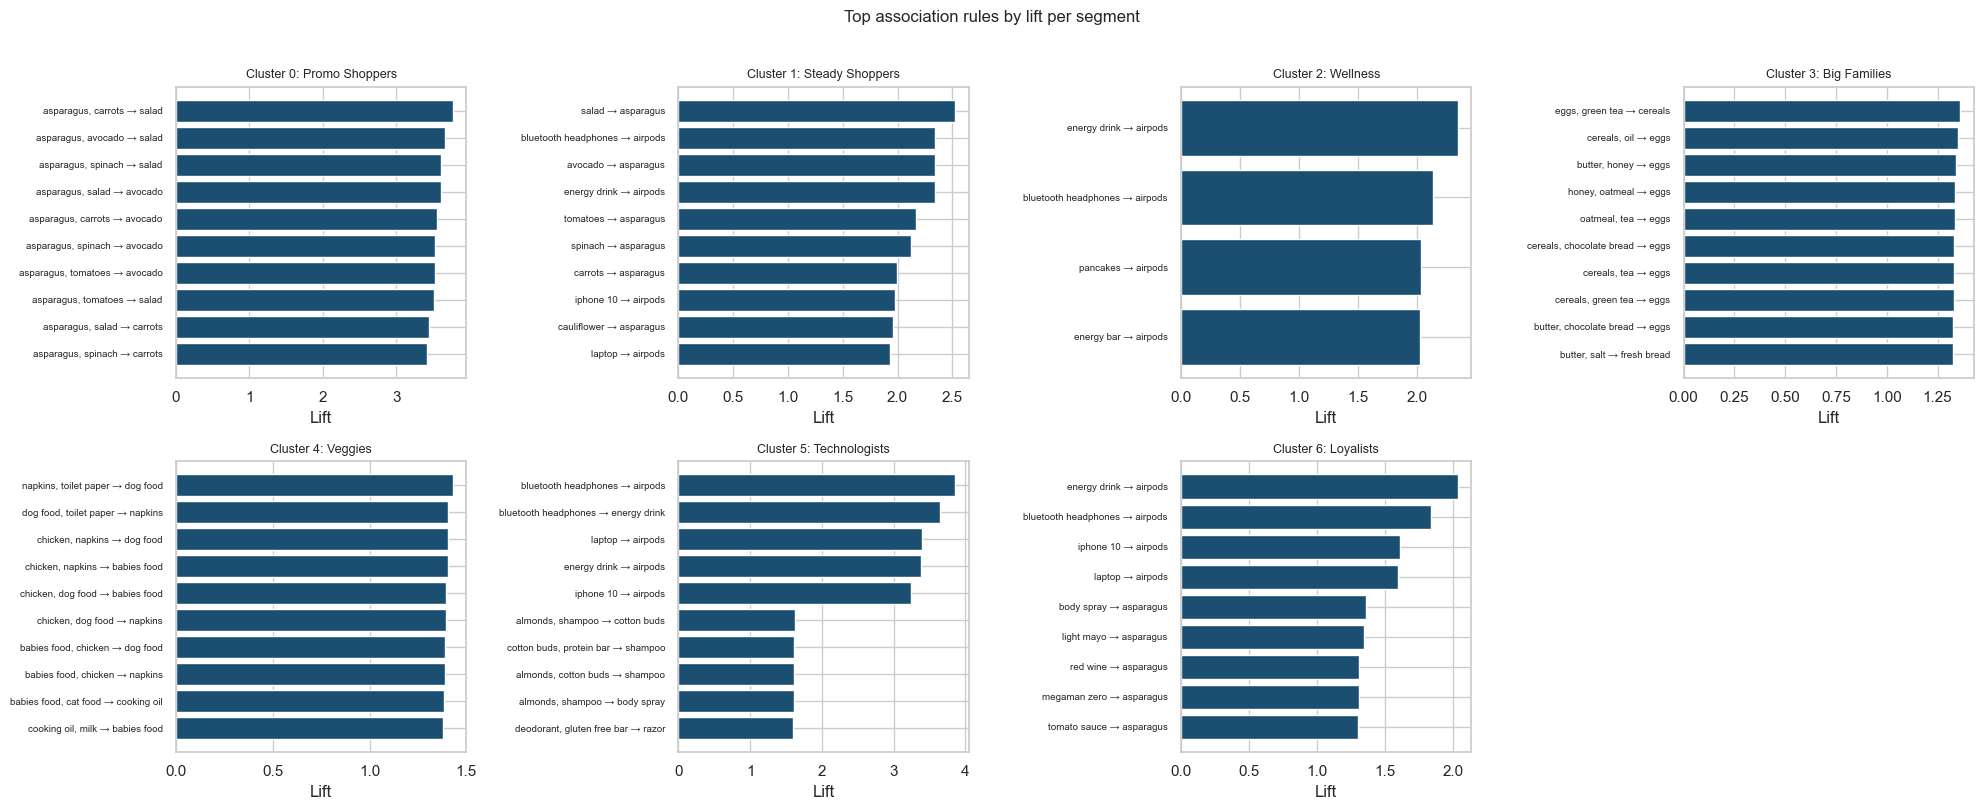

In [7]:
uar.plot_rules_by_segment(all_rules, CLUSTER_NAMES, n=10)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h2 style="margin:0;"><b>6) Campaign suggestions</b></h2>
<p style="margin:6px 0 0 0;">Each rule is translated into a concrete promotional action. The suggestions follow the rule logic: if a customer buys A, promote B.</p>
</div>

In [8]:
campaigns = uar.build_campaign_table(all_rules, CLUSTER_NAMES, n=3)
display(campaigns)

,cluster,segment,if_buys,promote,confidence,lift
0,0,Promo Shoppers,"asparagus, carrots",salad,0.42,3.76
1,0,Promo Shoppers,"asparagus, avocado",salad,0.41,3.67
2,0,Promo Shoppers,"asparagus, spinach",salad,0.41,3.61
3,1,Steady Shoppers,salad,asparagus,0.40,2.52
4,1,Steady Shoppers,bluetooth headphones,airpods,0.39,2.34
5,1,Steady Shoppers,avocado,asparagus,0.37,2.34
6,2,Wellness,energy drink,airpods,0.24,2.34
7,2,Wellness,bluetooth headphones,airpods,0.22,2.13
8,2,Wellness,pancakes,airpods,0.21,2.03
9,3,Big Families,"eggs, green tea",cereals,0.48,1.36


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
<b>How to read the campaign table.</b><br><br>
Each row is a promotion trigger: when a customer from a given segment purchases the items in <i>if_buys</i>, they should receive a targeted offer for the items in <i>promote</i>. Confidence indicates how often the consequent was purchased given the antecedent. Lift above 1 means the association is stronger than chance — higher lift implies a more actionable rule.
</div>

In [9]:
# Export campaign table
campaigns.to_csv(DATA_DIR / 'segment_campaign_rules.csv', index=False)
print('Saved segment_campaign_rules.csv')
print(f'Total campaign suggestions: {len(campaigns)}')

Saved segment_campaign_rules.csv
Total campaign suggestions: 21
